# Netflix Data Science Internship — Complete 5-Week Project

## End-to-End Data Science Analysis of Netflix Movies and TV Shows

This notebook integrates all five internship tasks into one reproducible workflow:

1. **Week 1:** Data Acquisition, Cleaning, and Exploratory Data Analysis
2. **Week 2:** Advanced Data Visualization and Storytelling
3. **Week 3:** Statistical Analysis and Hypothesis Testing
4. **Week 4:** Machine Learning Model Development and Evaluation
5. **Week 5:** Comprehensive Project Reporting and Strategic Recommendations

**Dataset:** Netflix Movies and TV Shows (`netflix_titles.csv`)

The notebook is designed to be executed from top to bottom after uploading the dataset.

## Project Objectives

- Prepare a clean and analysis-ready Netflix catalogue.
- Identify important patterns in content type, time, geography, genres, ratings, and duration.
- Communicate findings through advanced visualizations.
- Statistically test whether the Movie proportion is greater than a 65% reference benchmark.
- Build and evaluate a baseline machine-learning classifier for Movie vs TV Show.
- Translate the findings into strategic recommendations, business implications, limitations, and future work.

In [1]:
# ============================================================
# WEEK 1 TASK
# Data Acquisition, Cleaning, and Exploratory Data Analysis
# Dataset: Netflix Movies and TV Shows
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
# ============================================================
# 2. DATA ACQUISITION
# ============================================================

# After uploading netflix_titles.csv to Colab session storage:
file_path = "netflix_titles.csv"

try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'netflix_titles.csv' not found in session storage.")
    print("Please upload the file using the folder icon on the left sidebar.")

Dataset loaded successfully.


In [8]:
# ============================================================
# 3. INITIAL DATA INSPECTION
# ============================================================

if 'df' in locals() or 'df' in globals():
    print("Dataset Shape:")
    print(df.shape)

    print("\nFirst 5 rows:")
    display(df.head())
else:
    print("Error: The dataframe 'df' is not defined.")
    print("Please ensure 'netflix_titles.csv' is uploaded and that the previous data loading cell has run successfully.")

Dataset Shape:
(6234, 12)

First 5 rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


In [9]:
# Dataset information

print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6234 entries, 0 to 6233
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       6234 non-null   int64 
 1   type          6234 non-null   object
 2   title         6234 non-null   object
 3   director      4265 non-null   object
 4   cast          5664 non-null   object
 5   country       5758 non-null   object
 6   date_added    6223 non-null   object
 7   release_year  6234 non-null   int64 
 8   rating        6224 non-null   object
 9   duration      6234 non-null   object
 10  listed_in     6234 non-null   object
 11  description   6234 non-null   object
dtypes: int64(2), object(10)
memory usage: 584.6+ KB


In [10]:
# Column names

print("Column Names:")
print(df.columns.tolist())

Column Names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [11]:
# Statistical summary

print("Statistical Summary:")
display(df.describe(include="all").T)

Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,6234.0,NaN,NaN,NaN,76703679.319859,10942964.649885,247747.0,80035801.75,80163367.0,80244888.75,81235729.0
type,6234,2,Movie,4265,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,6234,6172,The Silence,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,4265,3301,"Raúl Campos, Jan Suter",18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,5664,5469,David Attenborough,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,5758,554,United States,2032,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,6223,1524,"January 1, 2020",122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,6234.0,NaN,NaN,NaN,2013.35932,8.81162,1925.0,2013.0,2016.0,2018.0,2020.0
rating,6224,14,TV-MA,2027,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,6234,201,1 Season,1321,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# ============================================================
# 4. MISSING VALUES
# ============================================================

missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().sum() / len(df) * 100
)

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

missing_summary = missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

display(missing_summary)

,Missing Values,Percentage
director,1969,31.584857
cast,570,9.143407
country,476,7.635547
date_added,11,0.176452
rating,10,0.160411
title,0,0.000000
show_id,0,0.000000
type,0,0.000000
release_year,0,0.000000
duration,0,0.000000


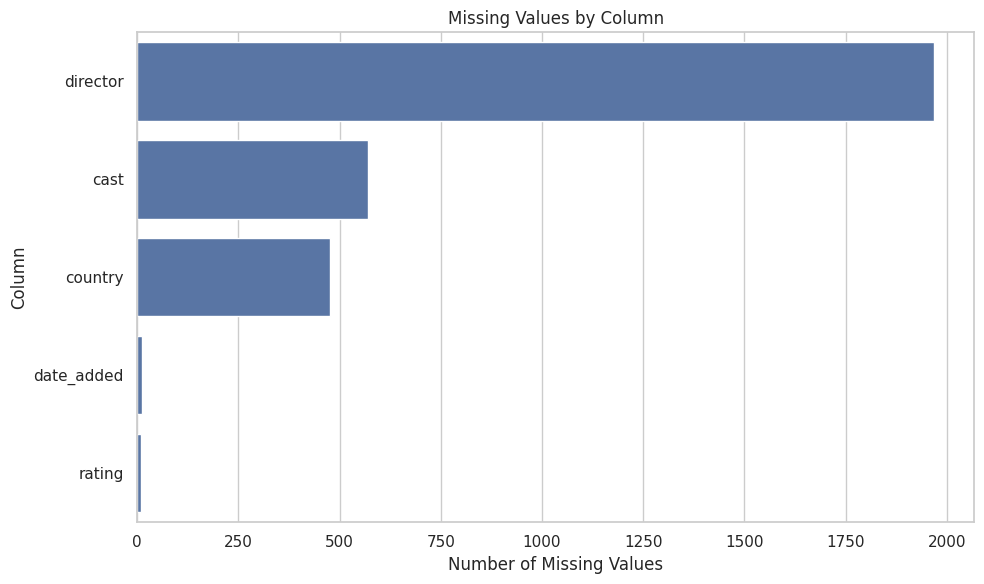

In [13]:
# ============================================================
# VISUALIZATION 1
# Missing Values by Column
# ============================================================

missing_plot = missing_summary[
    missing_summary["Missing Values"] > 0
]

plt.figure(figsize=(10, 6))

sns.barplot(
    x=missing_plot["Missing Values"],
    y=missing_plot.index
)

plt.title("Missing Values by Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Column")

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# 5. DUPLICATE RECORDS
# ============================================================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [15]:
# Remove duplicate records

if duplicate_count > 0:
    df = df.drop_duplicates().copy()

print("Dataset shape after duplicate removal:", df.shape)

Dataset shape after duplicate removal: (6234, 12)


In [16]:
# ============================================================
# 6. UNIQUE VALUE ANALYSIS
# ============================================================

for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")

show_id: 6234 unique values
type: 2 unique values
title: 6172 unique values
director: 3301 unique values
cast: 5469 unique values
country: 554 unique values
date_added: 1524 unique values
release_year: 72 unique values
rating: 14 unique values
duration: 201 unique values
listed_in: 461 unique values
description: 6226 unique values


In [17]:
# ============================================================
# 7. DATA TYPES
# ============================================================

print("Data types before cleaning:")
print(df.dtypes)

Data types before cleaning:
show_id          int64
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [18]:
# ============================================================
# 8. HANDLE MISSING VALUES
# ============================================================

# Make an explicit copy before modifying the dataframe
df = df.copy()

# Categorical columns where missing information should be retained
categorical_columns = [
    "director",
    "cast",
    "country"
]

for column in categorical_columns:
    if column in df.columns:
        df[column] = df[column].fillna("Unknown")

In [19]:
# Fill missing rating values with the mode

if "rating" in df.columns:
    rating_mode = df["rating"].mode()

    if not rating_mode.empty:
        df["rating"] = df["rating"].fillna(rating_mode.iloc[0])

In [20]:
# Convert date_added to datetime

if "date_added" in df.columns:

    df["date_added"] = pd.to_datetime(
        df["date_added"],
        errors="coerce"
    )

In [21]:
# ============================================================
# 9. REMOVE UNNECESSARY WHITESPACE
# ============================================================

object_columns = df.select_dtypes(
    include="object"
).columns

for column in object_columns:

    df[column] = df[column].apply(
        lambda x: x.strip() if isinstance(x, str) else x
    )

print("Whitespace cleaning completed.")

Whitespace cleaning completed.


In [22]:
# ============================================================
# 10. CREATE DATE FEATURES
# ============================================================

df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month
df["month_name"] = df["date_added"].dt.month_name()

print("Date features created successfully.")

Date features created successfully.


In [23]:
# ============================================================
# 11. FINAL DATA QUALITY CHECK
# ============================================================

final_missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": df.isnull().sum() / len(df) * 100
})

display(
    final_missing.sort_values(
        by="Missing Values",
        ascending=False
    )
)

,Missing Values,Percentage
date_added,651,10.442733
month_name,651,10.442733
month_added,651,10.442733
year_added,651,10.442733
title,0,0.000000
type,0,0.000000
show_id,0,0.000000
country,0,0.000000
cast,0,0.000000
director,0,0.000000


In [24]:
print("Remaining duplicate rows:", df.duplicated().sum())

Remaining duplicate rows: 0


In [25]:
# ============================================================
# 13. FINAL DATASET INFORMATION
# ============================================================

print("Final Dataset Shape:", df.shape)

print("\nFinal Data Types:")
print(df.dtypes)

print("\nFinal Dataset Information:")
df.info()

Final Dataset Shape: (6234, 15)

Final Data Types:
show_id                  int64
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
year_added             float64
month_added            float64
month_name              object
dtype: object

Final Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6234 entries, 0 to 6233
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       6234 non-null   int64         
 1   type          6234 non-null   object        
 2   title         6234 non-null   object        
 3   director      6234 non-null   object        
 4   cast          6234 non-null   

In [26]:
# ============================================================
# 14. SAVE CLEANED DATASET
# ============================================================

cleaned_file = "netflix_cleaned.csv"

df.to_csv(
    cleaned_file,
    index=False
)

print(f"Cleaned dataset saved as: {cleaned_file}")

Cleaned dataset saved as: netflix_cleaned.csv


In [27]:
# ============================================================
# EDA 1: MOVIES VS TV SHOWS
# ============================================================

content_type = df["type"].value_counts()

print("Content Type Distribution:")
display(content_type)

Content Type Distribution:


,count
type,
Movie,4265
TV Show,1969


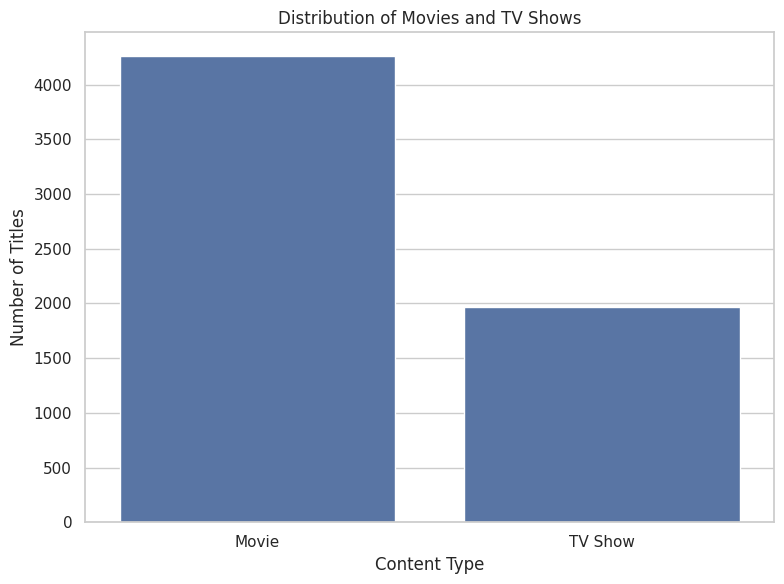

In [28]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=content_type.index,
    y=content_type.values
)

plt.title("Distribution of Movies and TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()

In [29]:
# Calculate percentages

content_percentage = (
    df["type"].value_counts(normalize=True) * 100
)

display(
    content_percentage.round(2)
)

,proportion
type,
Movie,68.42
TV Show,31.58


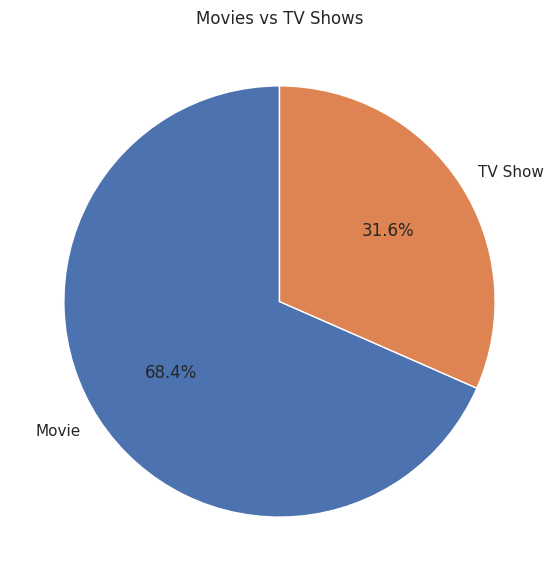

In [30]:
plt.figure(figsize=(7, 7))

plt.pie(
    content_type.values,
    labels=content_type.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Movies vs TV Shows")

plt.show()

In [31]:
# ============================================================
# EDA 2: CONTENT ADDED OVER TIME
# ============================================================

year_added_counts = (
    df["year_added"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

display(year_added_counts)

,count
year_added,
2008,2
2009,2
2010,1
2011,13
2012,7
2013,9
2014,19
2015,74
2016,412


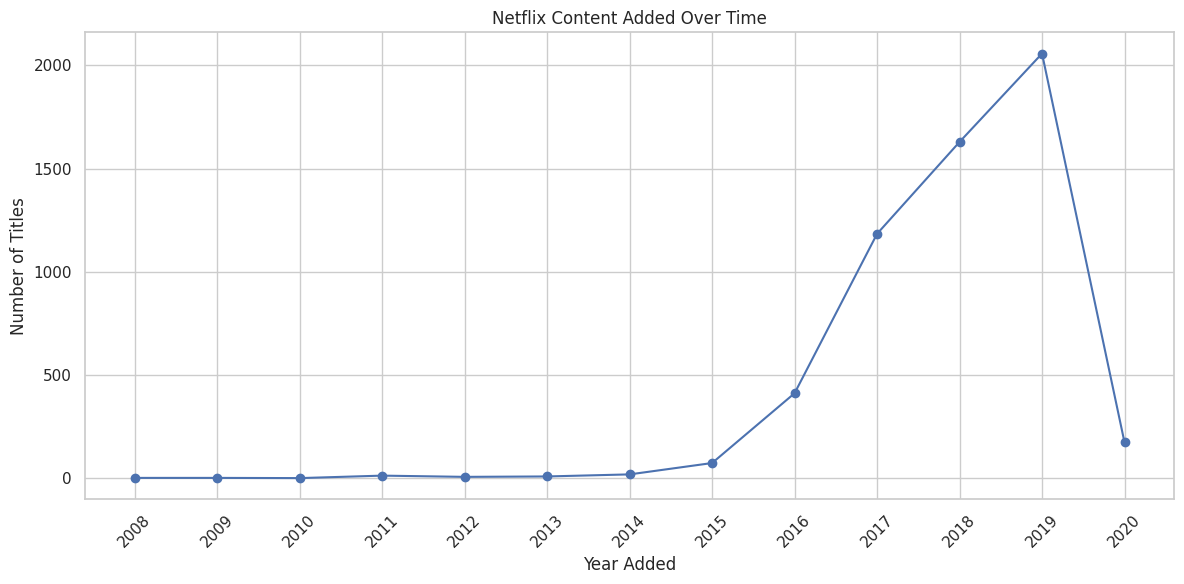

In [32]:
plt.figure(figsize=(12, 6))

plt.plot(
    year_added_counts.index,
    year_added_counts.values,
    marker="o"
)

plt.title("Netflix Content Added Over Time")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")

plt.xticks(
    year_added_counts.index,
    rotation=45
)

plt.tight_layout()
plt.show()

In [33]:
# ============================================================
# EDA 3: COUNTRY ANALYSIS
# ============================================================

country_data = (
    df["country"]
    .dropna()
    .astype(str)
    .str.split(", ")
    .explode()
    .str.strip()
)

country_counts = country_data.value_counts()

print("Top 20 countries:")
display(country_counts.head(20))

Top 20 countries:


,count
country,
United States,2609
India,838
United Kingdom,601
Unknown,476
Canada,318
France,271
Japan,231
Spain,178
South Korea,162


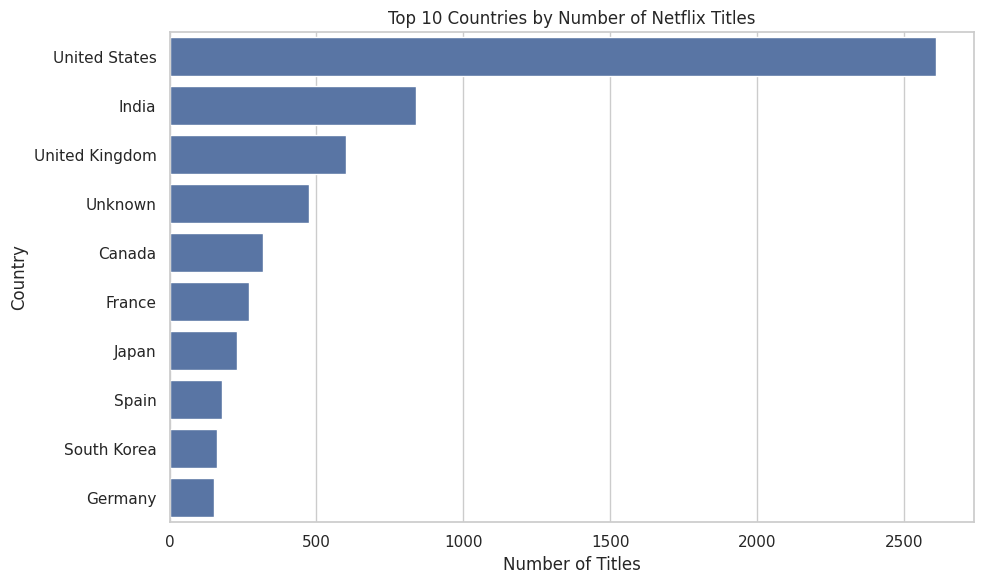

In [34]:
top_countries = country_counts.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [35]:
# ============================================================
# EDA 4: RELEASE YEAR
# ============================================================

print("Oldest release year:", df["release_year"].min())
print("Newest release year:", df["release_year"].max())
print(
    "Average release year:",
    round(df["release_year"].mean(), 2)
)

Oldest release year: 1925
Newest release year: 2020
Average release year: 2013.36


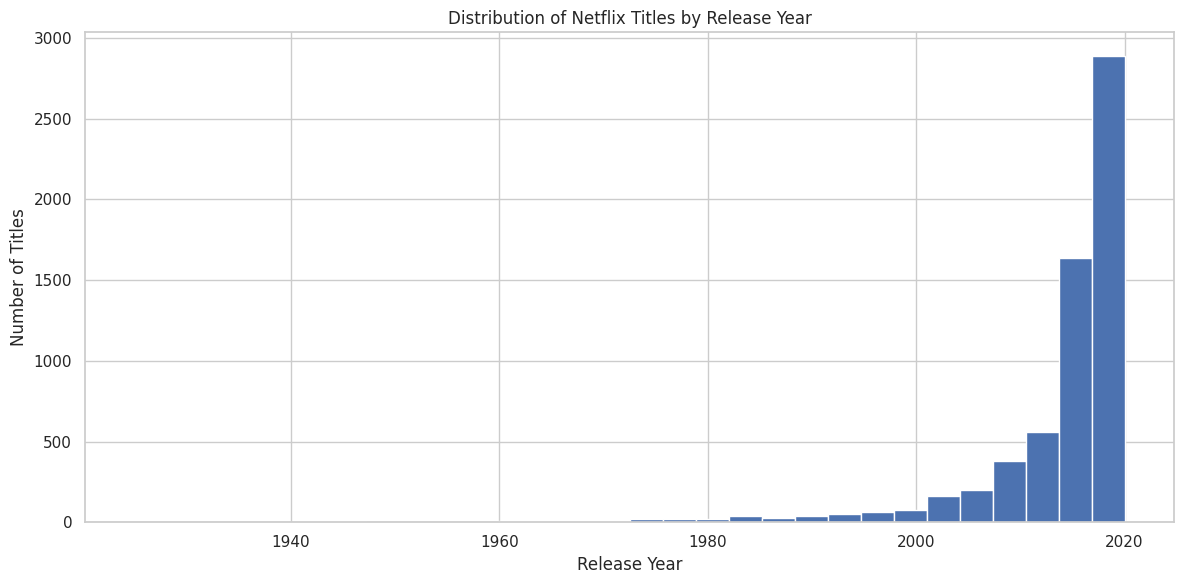

In [36]:
plt.figure(figsize=(12, 6))

plt.hist(
    df["release_year"],
    bins=30
)

plt.title("Distribution of Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()

In [37]:
# ============================================================
# EDA 5: CONTENT RATINGS
# ============================================================

rating_counts = df["rating"].value_counts()

print("Content Ratings:")
display(rating_counts)

Content Ratings:


,count
rating,
TV-MA,2037
TV-14,1698
TV-PG,701
R,508
PG-13,286
NR,218
PG,184
TV-Y7,169
TV-G,149


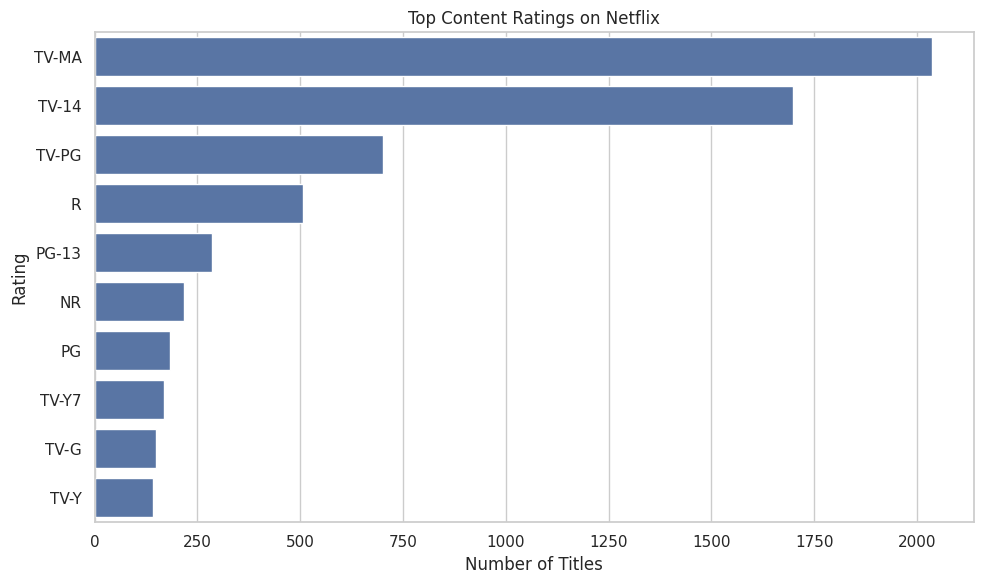

In [38]:
top_ratings = rating_counts.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_ratings.values,
    y=top_ratings.index
)

plt.title("Top Content Ratings on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()

In [39]:
# ============================================================
# EDA 6: MOVIE DURATION
# ============================================================

movies = df[df["type"] == "Movie"].copy()

movies["duration_minutes"] = (
    movies["duration"]
    .str.extract(r"(\d+)")
    .astype(float)
)

print("Movie duration statistics:")

display(
    movies["duration_minutes"].describe()
)

Movie duration statistics:


,duration_minutes
count,4265.000000
mean,99.100821
std,28.074857
min,3.000000
25%,86.000000
50%,98.000000
75%,115.000000
max,312.000000


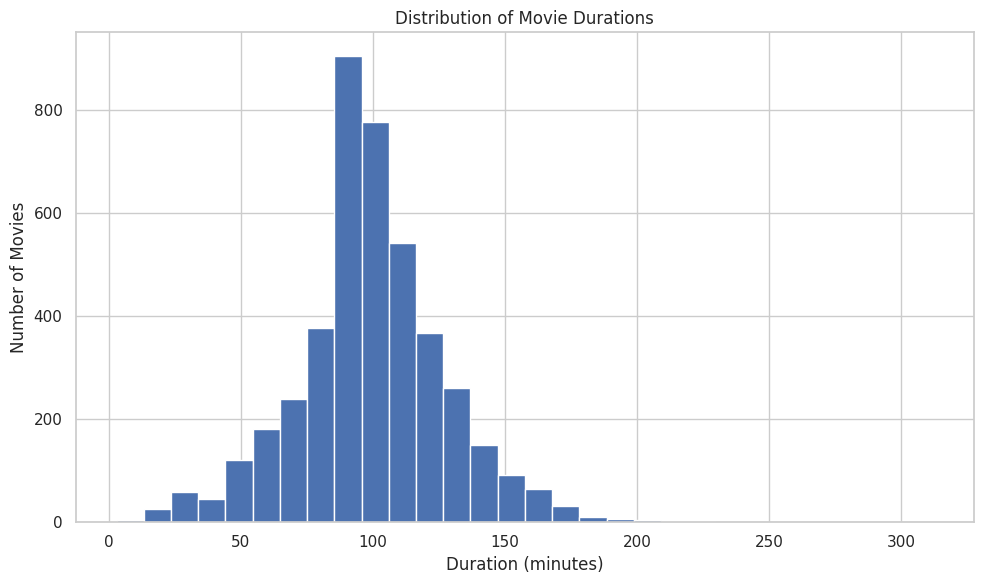

In [40]:
plt.figure(figsize=(10, 6))

plt.hist(
    movies["duration_minutes"].dropna(),
    bins=30
)

plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()

In [41]:

# ============================================================
# EDA 7: TV SHOW SEASONS
# ============================================================

tv_shows = df[df["type"] == "TV Show"].copy()

tv_shows["seasons"] = (
    tv_shows["duration"]
    .str.extract(r"(\d+)")
    .astype(float)
)

print("TV Show Season Statistics:")

display(
    tv_shows["seasons"].describe()
)

TV Show Season Statistics:


,seasons
count,1969.000000
mean,1.779584
std,1.624936
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,15.000000


In [42]:
# ============================================================
# EDA 8: GENRE ANALYSIS
# ============================================================

genre_data = (
    df["listed_in"]
    .dropna()
    .astype(str)
    .str.split(", ")
    .explode()
    .str.strip()
)

genre_counts = genre_data.value_counts()

print("Top 20 Genres:")
display(genre_counts.head(20))

Top 20 Genres:


,count
listed_in,
International Movies,1927
Dramas,1623
Comedies,1113
International TV Shows,1001
Documentaries,668
TV Dramas,599
Action & Adventure,597
Independent Movies,552
TV Comedies,436


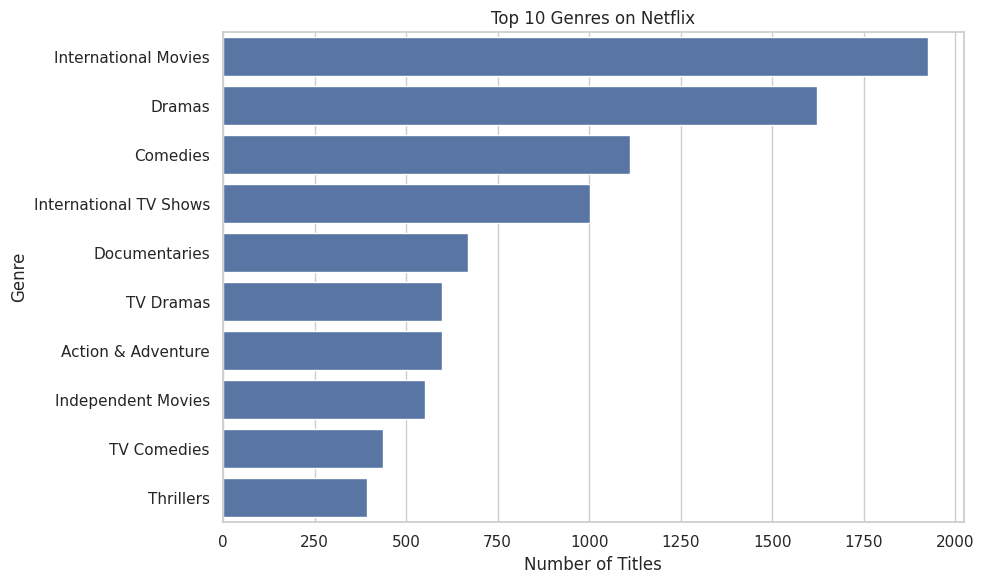

In [43]:
top_genres = genre_counts.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

In [44]:
# ============================================================
# EDA 9: CONTENT TYPE OVER RELEASE YEAR
# ============================================================

type_year = (
    df.groupby(
        ["release_year", "type"]
    )
    .size()
    .unstack(fill_value=0)
)

display(type_year.tail(20))

type,Movie,TV Show
release_year,,
2001,30,4
2002,35,3
2003,35,8
2004,40,9
2005,51,12
2006,59,9
2007,60,11
2008,87,20
2009,87,34


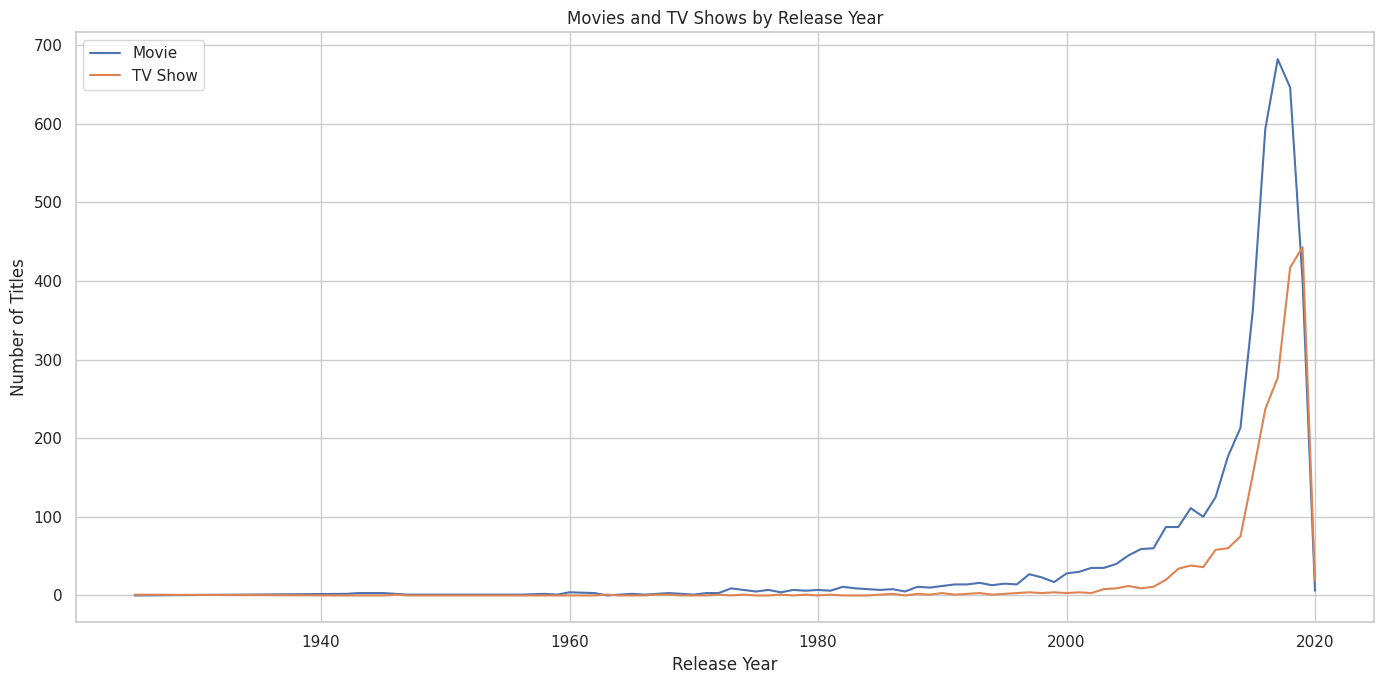

In [45]:
plt.figure(figsize=(14, 7))

if "Movie" in type_year.columns:
    plt.plot(
        type_year.index,
        type_year["Movie"],
        label="Movie"
    )

if "TV Show" in type_year.columns:
    plt.plot(
        type_year.index,
        type_year["TV Show"],
        label="TV Show"
    )

plt.title("Movies and TV Shows by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.legend()

plt.tight_layout()
plt.show()

In [46]:
# ============================================================
# EDA 10: CORRELATION ANALYSIS
# ============================================================

correlation_df = df[
    [
        "release_year",
        "year_added"
    ]
].copy()

correlation_df = correlation_df.dropna()

correlation_matrix = correlation_df.corr()

display(correlation_matrix)

,release_year,year_added
release_year,1.000000,0.023812
year_added,0.023812,1.000000


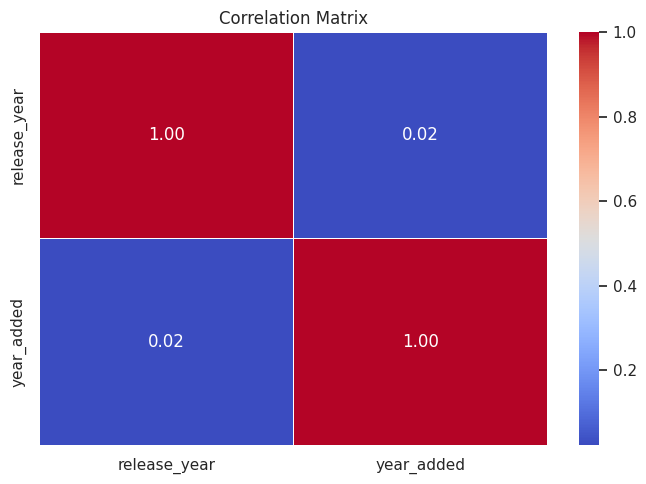

In [47]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [48]:
# ============================================================
# 26. SUMMARY STATISTICS
# ============================================================

print("Numerical Summary:")

display(
    df[
        ["release_year", "year_added"]
    ].describe()
)

Numerical Summary:


,release_year,year_added
count,6234.00000,5583.000000
mean,2013.35932,2017.977611
std,8.81162,1.204033
min,1925.00000,2008.000000
25%,2013.00000,2017.000000
50%,2016.00000,2018.000000
75%,2018.00000,2019.000000
max,2020.00000,2020.000000


In [49]:
# ============================================================
# 27. AUTOMATIC SUMMARY
# ============================================================

total_titles = len(df)

movies_count = (
    (df["type"] == "Movie").sum()
)

tv_count = (
    (df["type"] == "TV Show").sum()
)

movie_percentage = movies_count / total_titles * 100
tv_percentage = tv_count / total_titles * 100

print("========== DATASET SUMMARY ==========")

print("Total titles:", total_titles)

print(
    f"Movies: {movies_count} "
    f"({movie_percentage:.2f}%)"
)

print(
    f"TV Shows: {tv_count} "
    f"({tv_percentage:.2f}%)"
)

print(
    "Oldest release year:",
    df["release_year"].min()
)

print(
    "Newest release year:",
    df["release_year"].max()
)

print(
    "Most common rating:",
    df["rating"].mode()[0]
)

print(
    "Top country:",
    country_counts.index[0]
)

print(
    "Top genre:",
    genre_counts.index[0]
)

========== DATASET SUMMARY ==========
Total titles: 6234
Movies: 4265 (68.42%)
TV Shows: 1969 (31.58%)
Oldest release year: 1925
Newest release year: 2020
Most common rating: TV-MA
Top country: United States
Top genre: International Movies


In [50]:
# ============================================================
# DATA QUALITY REPORT
# ============================================================

print("Final Data Quality Report")
print("=" * 50)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print(
    "Duplicate rows:",
    df.duplicated().sum()
)

print(
    "Total missing values:",
    df.isnull().sum().sum()
)

print("\nMissing values by column:")

display(
    df.isnull().sum()
    .sort_values(ascending=False)
)

Final Data Quality Report
Rows: 6234
Columns: 15
Duplicate rows: 0
Total missing values: 2604

Missing values by column:


,0
date_added,651
month_name,651
month_added,651
year_added,651
title,0
type,0
show_id,0
country,0
cast,0
director,0


In [51]:
# ============================================================
# 29. EXPORT IMPORTANT RESULTS
# ============================================================

country_counts.head(20).to_csv(
    "top_countries.csv"
)

genre_counts.head(20).to_csv(
    "top_genres.csv"
)

rating_counts.to_csv(
    "rating_distribution.csv"
)

content_type.to_csv(
    "content_type_distribution.csv"
)

year_added_counts.to_csv(
    "content_added_by_year.csv"
)

print("EDA result files exported successfully.")

EDA result files exported successfully.


In [52]:
# ============================================================
# FINAL OUTPUT
# ============================================================

print("=" * 60)
print("WEEK 1 DATA PREPARATION COMPLETED")
print("=" * 60)

print("\nFinal Dataset Shape:", df.shape)

print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

print(
    "Total Missing Values:",
    df.isnull().sum().sum()
)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 cleaned records:")
display(df.head())

WEEK 1 DATA PREPARATION COMPLETED

Final Dataset Shape: (6234, 15)
Duplicate Rows: 0
Total Missing Values: 2604

Columns:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'year_added', 'month_added', 'month_name']

First 5 cleaned records:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,month_name
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China",2019-09-09,2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...,2019.0,9.0,September
1,80117401,Movie,Jandino: Whatever it Takes,Unknown,Jandino Asporaat,United Kingdom,2016-09-09,2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...,2016.0,9.0,September
2,70234439,TV Show,Transformers Prime,Unknown,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,2018-09-08,2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob...",2018.0,9.0,September
3,80058654,TV Show,Transformers: Robots in Disguise,Unknown,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,2018-09-08,2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...,2018.0,9.0,September
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,2017-09-08,2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...,2017.0,9.0,September


# WEEK 2 — Advanced Data Visualization and Storytelling

## Objective

The goal of Week 2 is to transform the cleaned data into a visual narrative that communicates important patterns to both technical and non-technical audiences.

The visual analysis focuses on:

- Content additions over time
- Geographic distribution
- Genre/category distribution
- Content ratings
- Movie duration
- TV Show seasons
- Content type by release year
- Relationships between release year and year added

In [53]:
# ============================================================
# WEEK 2 — ADVANCED VISUALIZATION SETUP
# ============================================================

# Reusable plotting helper
def show_title(title, subtitle=None):
    print("\n" + "=" * 70)
    print(title)
    if subtitle:
        print(subtitle)
    print("=" * 70)

show_title("WEEK 2 — ADVANCED DATA VISUALIZATION")


WEEK 2 — ADVANCED DATA VISUALIZATION


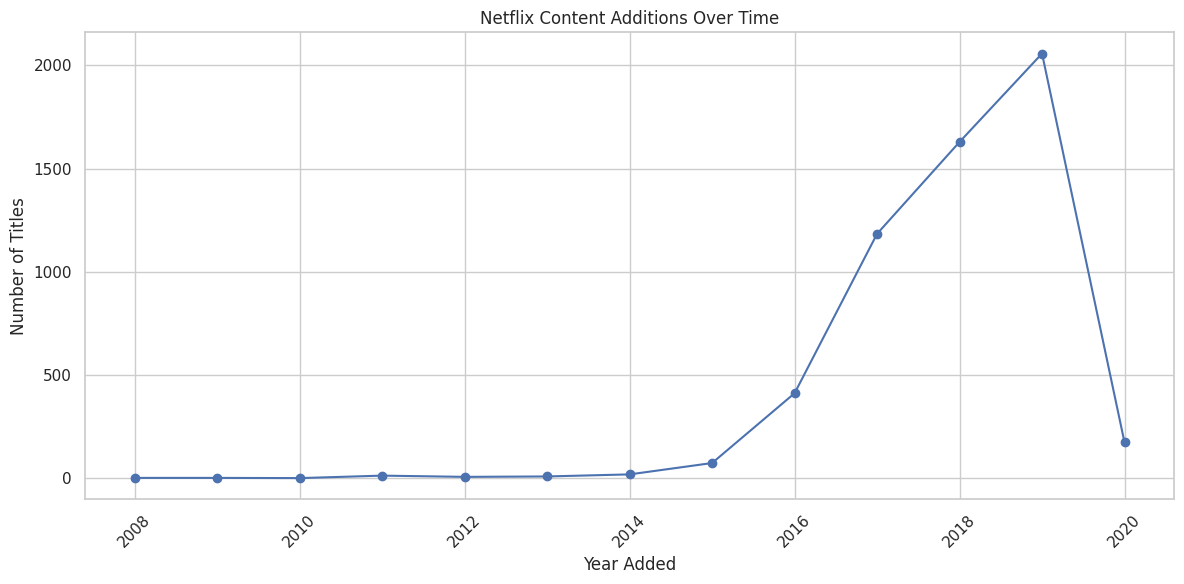

Peak year for additions: 2019 with 2057 titles.


In [54]:
# ============================================================
# WEEK 2.1 — CONTENT ADDITIONS OVER TIME
# ============================================================

year_added_counts = (
    df["year_added"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 6))
plt.plot(year_added_counts.index, year_added_counts.values, marker="o")
plt.title("Netflix Content Additions Over Time")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Peak year for additions:",
      int(year_added_counts.idxmax()),
      "with", int(year_added_counts.max()), "titles.")

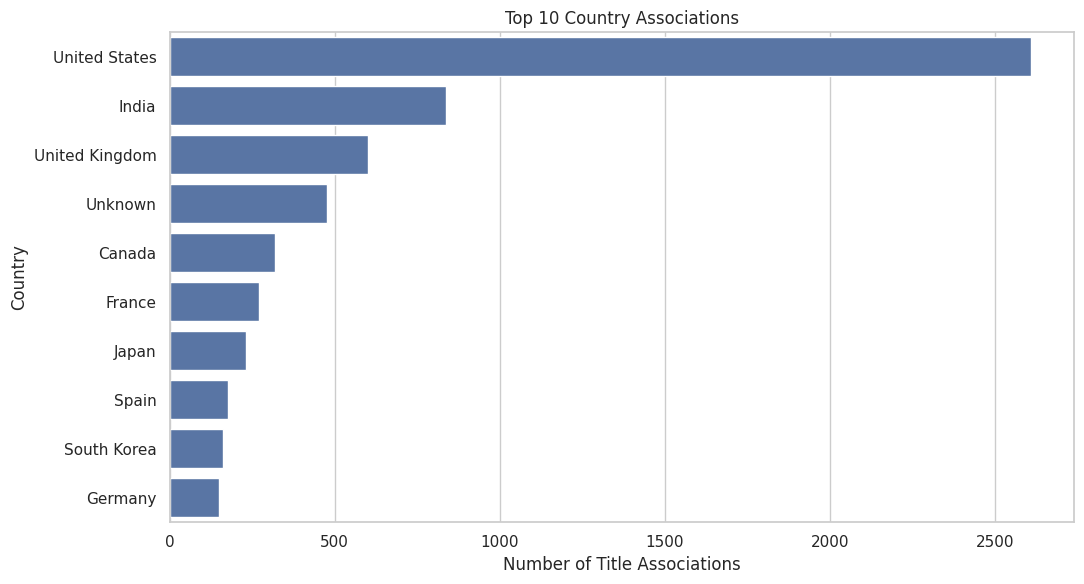

Top country association: United States with 2609 title associations.


In [55]:
# ============================================================
# WEEK 2.2 — TOP COUNTRIES
# ============================================================

country_data = (
    df["country"]
    .dropna()
    .astype(str)
    .str.split(", ")
    .explode()
    .str.strip()
)

country_counts = country_data.value_counts()
top_countries = country_counts.head(10)

plt.figure(figsize=(11, 6))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Country Associations")
plt.xlabel("Number of Title Associations")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

print("Top country association:", country_counts.index[0],
      "with", int(country_counts.iloc[0]), "title associations.")

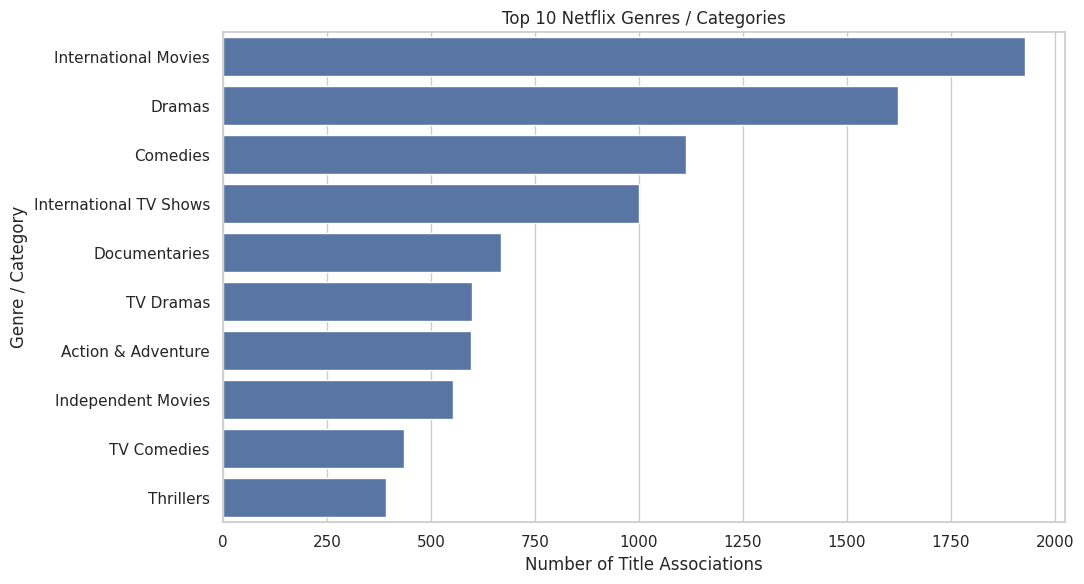

Top genre/category: International Movies with 1927 title associations.


In [56]:
# ============================================================
# WEEK 2.3 — TOP GENRES / CATEGORIES
# ============================================================

genre_data = (
    df["listed_in"]
    .dropna()
    .astype(str)
    .str.split(", ")
    .explode()
    .str.strip()
)

genre_counts = genre_data.value_counts()
top_genres = genre_counts.head(10)

plt.figure(figsize=(11, 6))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Netflix Genres / Categories")
plt.xlabel("Number of Title Associations")
plt.ylabel("Genre / Category")
plt.tight_layout()
plt.show()

print("Top genre/category:", genre_counts.index[0],
      "with", int(genre_counts.iloc[0]), "title associations.")

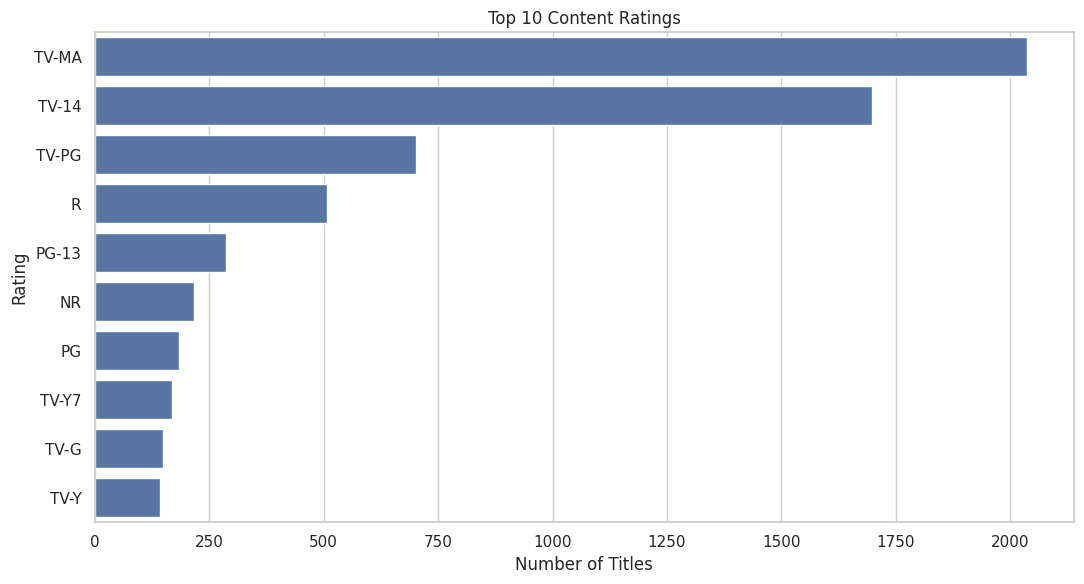

Most common rating: TV-MA


In [57]:
# ============================================================
# WEEK 2.4 — CONTENT RATINGS
# ============================================================

rating_counts = df["rating"].value_counts()

plt.figure(figsize=(11, 6))
sns.barplot(x=rating_counts.head(10).values,
            y=rating_counts.head(10).index)
plt.title("Top 10 Content Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

print("Most common rating:", rating_counts.index[0])

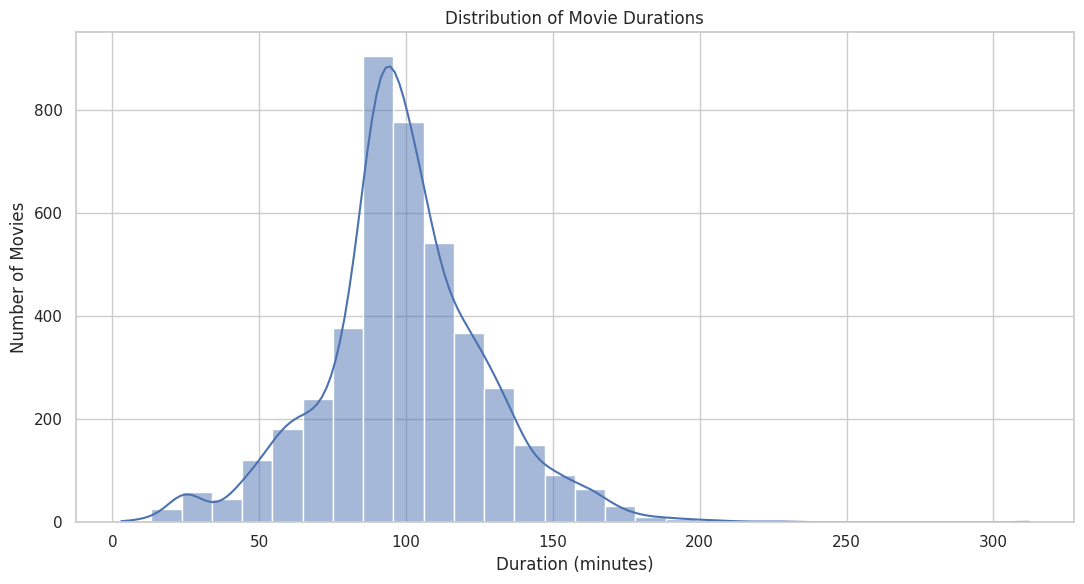

Median movie duration: 98.0 minutes


In [58]:
# ============================================================
# WEEK 2.5 — MOVIE DURATION DISTRIBUTION
# ============================================================

movies = df[df["type"] == "Movie"].copy()

movies["duration_minutes"] = pd.to_numeric(
    movies["duration"].astype(str).str.extract(r"(\d+)")[0],
    errors="coerce"
)

plt.figure(figsize=(11, 6))
sns.histplot(movies["duration_minutes"].dropna(), bins=30, kde=True)
plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

print("Median movie duration:",
      round(movies["duration_minutes"].median(), 2), "minutes")

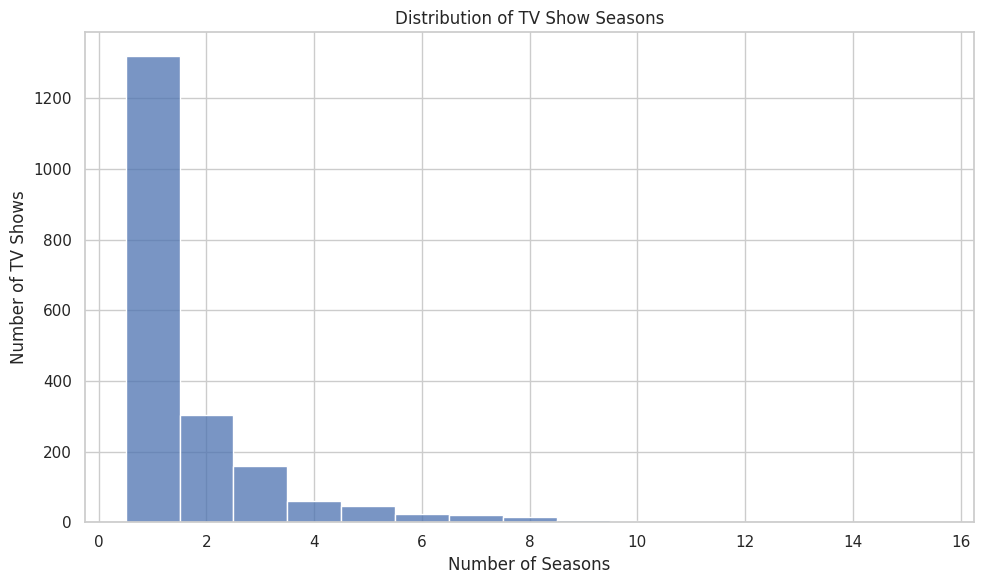

Average TV Show seasons: 1.78


In [59]:
# ============================================================
# WEEK 2.6 — TV SHOW SEASONS
# ============================================================

tv_shows = df[df["type"] == "TV Show"].copy()

tv_shows["seasons"] = pd.to_numeric(
    tv_shows["duration"].astype(str).str.extract(r"(\d+)")[0],
    errors="coerce"
)

plt.figure(figsize=(10, 6))
sns.histplot(tv_shows["seasons"].dropna(), bins=15, discrete=True)
plt.title("Distribution of TV Show Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")
plt.tight_layout()
plt.show()

print("Average TV Show seasons:",
      round(tv_shows["seasons"].mean(), 2))

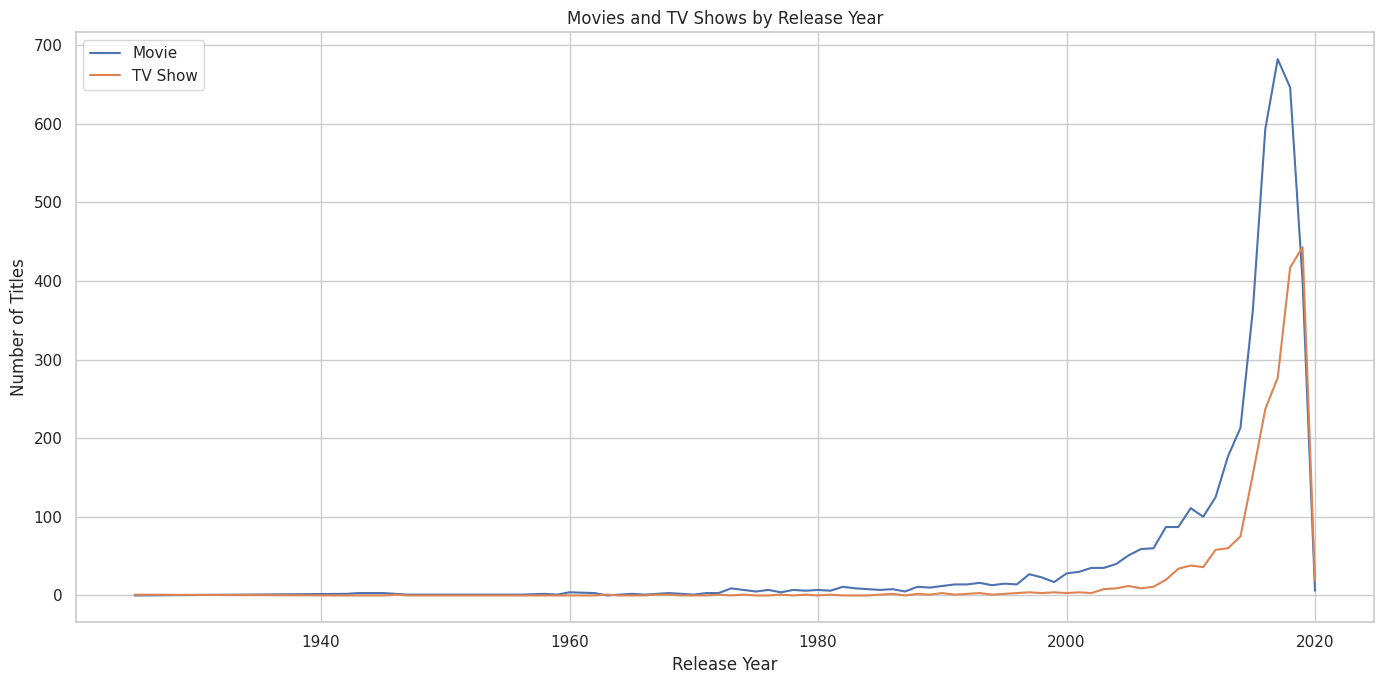

In [60]:
# ============================================================
# WEEK 2.7 — MOVIE VS TV SHOW BY RELEASE YEAR
# ============================================================

type_year = (
    df.groupby(["release_year", "type"])
      .size()
      .unstack(fill_value=0)
)

plt.figure(figsize=(14, 7))

for content_type_name in ["Movie", "TV Show"]:
    if content_type_name in type_year.columns:
        plt.plot(type_year.index,
                 type_year[content_type_name],
                 label=content_type_name)

plt.title("Movies and TV Shows by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.legend()
plt.tight_layout()
plt.show()

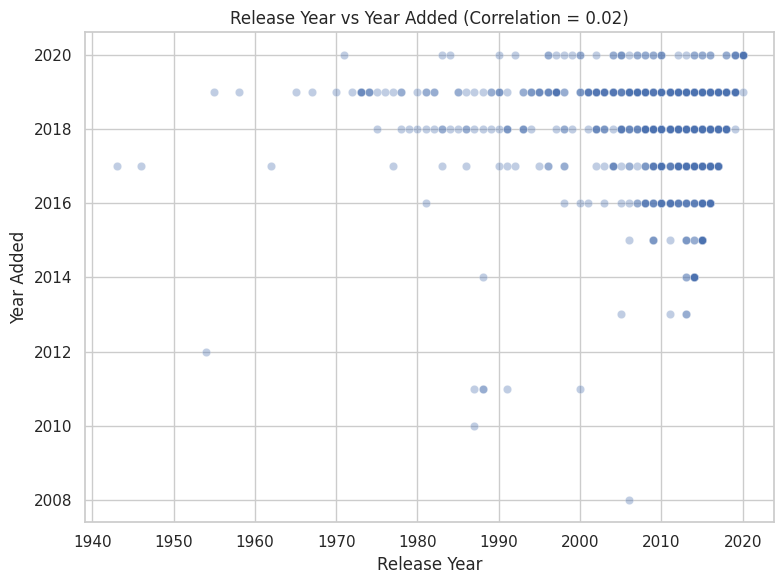

Pearson correlation: 0.0238


In [61]:
# ============================================================
# WEEK 2.8 — RELEASE YEAR VS YEAR ADDED
# ============================================================

correlation_df = df[["release_year", "year_added"]].dropna()
corr_value = correlation_df["release_year"].corr(
    correlation_df["year_added"]
)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=correlation_df.sample(
        min(2000, len(correlation_df)),
        random_state=42
    ),
    x="release_year",
    y="year_added",
    alpha=0.35
)
plt.title(f"Release Year vs Year Added (Correlation = {corr_value:.2f})")
plt.xlabel("Release Year")
plt.ylabel("Year Added")
plt.tight_layout()
plt.show()

print("Pearson correlation:", round(corr_value, 4))

## Week 2 — Storytelling Summary

The visualizations should be interpreted as a connected story rather than as isolated charts.

Key questions for the reader:

- When did catalogue additions accelerate?
- Which countries have the largest title associations?
- Which genres/categories dominate?
- What audience-rating categories are most common?
- What is the typical movie duration?
- How does the catalogue differ between Movies and TV Shows?

**Important interpretation note:** country and genre fields can contain multiple values for a single title. Therefore, their counts represent associations, not mutually exclusive market shares.

# WEEK 3 — Statistical Analysis and Hypothesis Testing

## Research Question

Is the proportion of Movies in the dataset significantly greater than **65%**?

### Hypotheses

- **H₀:** Movie proportion is 65% or less.
- **H₁:** Movie proportion is greater than 65%.
- **Significance level:** α = 0.05.

Two complementary tests are used:

1. One-sample proportion z-test
2. Chi-square goodness-of-fit test

A 95% confidence interval is also calculated for the observed Movie proportion.

In [62]:
# ============================================================
# WEEK 3.1 — PREPARE THE HYPOTHESIS-TEST DATA
# ============================================================

from scipy.stats import chisquare
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

content = df["type"].dropna()

movie_count = int((content == "Movie").sum())
tv_count = int((content == "TV Show").sum())
n = len(content)

movie_proportion = movie_count / n

print("Total observations:", n)
print("Movie count:", movie_count)
print("TV Show count:", tv_count)
print("Observed Movie proportion:", round(movie_proportion, 4))
print("Observed Movie percentage:", round(movie_proportion * 100, 2), "%")

Total observations: 6234
Movie count: 4265
TV Show count: 1969
Observed Movie proportion: 0.6842
Observed Movie percentage: 68.42 %


In [63]:
# ============================================================
# WEEK 3.2 — ONE-SAMPLE PROPORTION Z-TEST
# ============================================================

p0 = 0.65

z_stat, p_value = proportions_ztest(
    count=movie_count,
    nobs=n,
    value=p0,
    alternative="larger"
)

print("One-sample proportion z-test")
print("-" * 45)
print("Null proportion:", p0)
print("z-statistic:", round(z_stat, 4))
print("p-value:", p_value)

if p_value < 0.05:
    print("Decision: Reject H0 at α = 0.05.")
    print("Conclusion: There is statistically significant evidence that")
    print("the Movie proportion is greater than 65%.")
else:
    print("Decision: Fail to reject H0 at α = 0.05.")

One-sample proportion z-test
---------------------------------------------
Null proportion: 0.65
z-statistic: 5.8007
p-value: 3.302911594510915e-09
Decision: Reject H0 at α = 0.05.
Conclusion: There is statistically significant evidence that
the Movie proportion is greater than 65%.


In [64]:
# ============================================================
# WEEK 3.3 — CHI-SQUARE GOODNESS-OF-FIT TEST
# ============================================================

observed = np.array([movie_count, tv_count])

expected = np.array([
    n * 0.65,
    n * 0.35
])

chi2_stat, chi2_p = chisquare(
    f_obs=observed,
    f_exp=expected
)

print("Chi-square goodness-of-fit test")
print("-" * 45)
print("Observed:", observed)
print("Expected:", expected.round(2))
print("Chi-square statistic:", round(chi2_stat, 4))
print("p-value:", chi2_p)

if chi2_p < 0.05:
    print("Decision: Reject H0.")
else:
    print("Decision: Fail to reject H0.")

Chi-square goodness-of-fit test
---------------------------------------------
Observed: [4265 1969]
Expected: [4052.1 2181.9]
Chi-square statistic: 31.9597
p-value: 1.5740184556586458e-08
Decision: Reject H0.


95% Confidence Interval for Movie Proportion
--------------------------------------------------
Lower bound: 67.26 %
Upper bound: 69.57 %


ValueError: 'xerr' (shape: (1, 2)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'x' (shape: (1,))

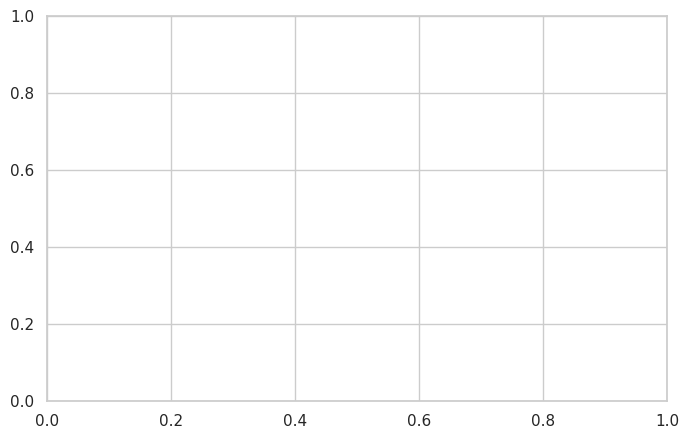

In [65]:
# ============================================================
# WEEK 3.4 — 95% CONFIDENCE INTERVAL
# ============================================================

ci_low, ci_high = proportion_confint(
    count=movie_count,
    nobs=n,
    alpha=0.05,
    method="normal"
)

print("95% Confidence Interval for Movie Proportion")
print("-" * 50)
print("Lower bound:", round(ci_low * 100, 2), "%")
print("Upper bound:", round(ci_high * 100, 2), "%")

plt.figure(figsize=(8, 5))
plt.errorbar(
    x=[movie_proportion * 100],
    y=[0],
    xerr=[[
        movie_proportion * 100 - ci_low * 100,
        ci_high * 100 - movie_proportion * 100
    ]],
    fmt="o"
)
plt.axvline(65, linestyle="--", label="65% benchmark")
plt.yticks([])
plt.xlabel("Movie Proportion (%)")
plt.title("Movie Proportion with 95% Confidence Interval")
plt.legend()
plt.tight_layout()
plt.show()

In [66]:
# ============================================================
# WEEK 3.5 — STATISTICAL RESULTS SUMMARY
# ============================================================

week3_results = pd.DataFrame({
    "Measure": [
        "Observed Movie proportion",
        "One-sample z statistic",
        "One-sample z-test p-value",
        "Chi-square statistic",
        "Chi-square p-value",
        "95% CI lower bound",
        "95% CI upper bound"
    ],
    "Result": [
        movie_proportion,
        z_stat,
        p_value,
        chi2_stat,
        chi2_p,
        ci_low,
        ci_high
    ]
})

display(week3_results)

,Measure,Result
0,Observed Movie proportion,6.841514e-01
1,One-sample z statistic,5.800650e+00
2,One-sample z-test p-value,3.302912e-09
3,Chi-square statistic,3.195973e+01
4,Chi-square p-value,1.574018e-08
5,95% CI lower bound,6.726121e-01
6,95% CI upper bound,6.956907e-01


## Week 3 Interpretation

If the p-value is below 0.05, the null hypothesis is rejected. The correct conclusion is limited to the selected dataset and 65% reference benchmark.

**Statistical significance does not prove causation.** It also does not automatically imply that the observed difference is strategically important.

# WEEK 4 — Machine Learning Model Development and Evaluation

## Objective

Build a baseline supervised-learning model to classify a title as:

- **Movie**
- **TV Show**

### Features

The baseline uses:

- `release_year`
- `rating`
- `duration`

The categorical variables are one-hot encoded. The model is a Decision Tree because it is interpretable and can capture non-linear relationships.

### Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix
- ROC-AUC

In [67]:
# ============================================================
# WEEK 4.1 — PREPARE MACHINE LEARNING DATA
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

ml_df = df[["type", "release_year", "rating", "duration"]].copy()

# Target
ml_df = ml_df[ml_df["type"].isin(["Movie", "TV Show"])].copy()
y = ml_df["type"]

X = ml_df[["release_year", "rating", "duration"]]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Training class distribution:")
display(y_train.value_counts())

Training rows: 4987
Testing rows: 1247
Training class distribution:


,count
type,
Movie,3412
TV Show,1575


In [68]:
# ============================================================
# WEEK 4.2 — PREPROCESSING + DECISION TREE
# ============================================================

categorical_features = ["rating", "duration"]
numeric_features = ["release_year"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        ),
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            numeric_features
        )
    ]
)

model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        DecisionTreeClassifier(
            max_depth=5,
            min_samples_leaf=20,
            random_state=42
        )
    )
])

model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [69]:
# ============================================================
# WEEK 4.3 — PREDICTIONS AND METRICS
# ============================================================

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

# Identify the probability column for TV Show
class_names = list(model.named_steps["classifier"].classes_)
tv_index = class_names.index("TV Show")
tv_probability = y_prob[:, tv_index]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(
    y_test, y_pred,
    pos_label="TV Show",
    zero_division=0
)
recall = recall_score(
    y_test, y_pred,
    pos_label="TV Show",
    zero_division=0
)
f1 = f1_score(
    y_test, y_pred,
    pos_label="TV Show",
    zero_division=0
)
roc_auc = roc_auc_score(
    (y_test == "TV Show").astype(int),
    tv_probability
)

ml_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision (TV Show)",
        "Recall (TV Show)",
        "F1-score (TV Show)",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

display(ml_results)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

,Metric,Score
0,Accuracy,0.989575
1,Precision (TV Show),1.000000
2,Recall (TV Show),0.967005
3,F1-score (TV Show),0.983226
4,ROC-AUC,0.983503



Classification Report:
              precision    recall  f1-score   support

       Movie       0.98      1.00      0.99       853
     TV Show       1.00      0.97      0.98       394

    accuracy                           0.99      1247
   macro avg       0.99      0.98      0.99      1247
weighted avg       0.99      0.99      0.99      1247



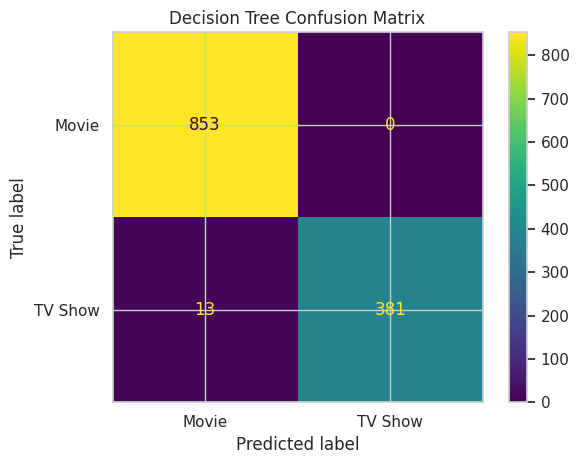

Confusion matrix:


,Predicted Movie,Predicted TV Show
Actual Movie,853,0
Actual TV Show,13,381


In [70]:
# ============================================================
# WEEK 4.4 — CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Movie", "TV Show"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Movie", "TV Show"]
)

disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()

print("Confusion matrix:")
display(pd.DataFrame(
    cm,
    index=["Actual Movie", "Actual TV Show"],
    columns=["Predicted Movie", "Predicted TV Show"]
))

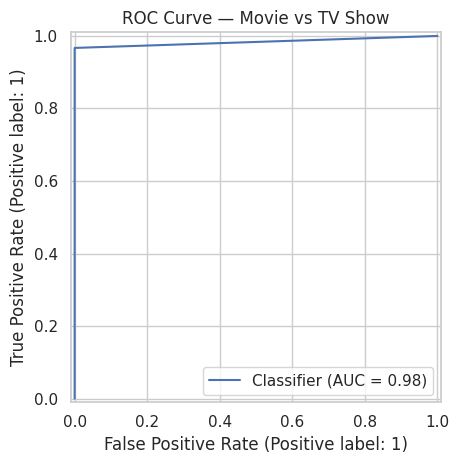

In [71]:
# ============================================================
# WEEK 4.5 — ROC CURVE
# ============================================================

RocCurveDisplay.from_predictions(
    (y_test == "TV Show").astype(int),
    tv_probability
)

plt.title("ROC Curve — Movie vs TV Show")
plt.tight_layout()
plt.show()

In [72]:
# ============================================================
# WEEK 4.6 — TRAIN VS TEST ACCURACY
# ============================================================

train_pred = model.predict(X_train)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, y_pred)

print("Training accuracy:", round(train_accuracy, 4))
print("Test accuracy:", round(test_accuracy, 4))
print("Accuracy gap:", round(train_accuracy - test_accuracy, 4))

Training accuracy: 0.9868
Test accuracy: 0.9896
Accuracy gap: -0.0028


## Week 4 — Critical Model Interpretation

A very high classification score should **not** automatically be interpreted as production-ready predictive performance.

The `duration` field is especially important because:

- Movies generally have durations expressed in minutes.
- TV Shows generally have durations expressed as seasons.

Therefore, duration can act as a strong proxy for the target variable. This can make the classification problem much easier than a realistic recommendation or audience-prediction problem.

For a production model, the next step should be to compare results **with and without duration**, use cross-validation, and test additional algorithms.

In [73]:
# ============================================================
# WEEK 4.7 — OPTIONAL ABLATION TEST WITHOUT DURATION
# ============================================================

# This checks how much the model relies on the duration feature.

X_no_duration = ml_df[["release_year", "rating"]]

Xtr, Xte, ytr, yte = train_test_split(
    X_no_duration,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

preprocessor_no_duration = ColumnTransformer(
    transformers=[
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            ["rating"]
        ),
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            ["release_year"]
        )
    ]
)

model_no_duration = Pipeline([
    ("preprocessor", preprocessor_no_duration),
    (
        "classifier",
        DecisionTreeClassifier(
            max_depth=5,
            min_samples_leaf=20,
            random_state=42
        )
    )
])

model_no_duration.fit(Xtr, ytr)
pred_no_duration = model_no_duration.predict(Xte)

print(
    "Accuracy with duration:",
    round(accuracy, 4)
)
print(
    "Accuracy without duration:",
    round(accuracy_score(yte, pred_no_duration), 4)
)

Accuracy with duration: 0.9896
Accuracy without duration: 0.6905


# WEEK 5 — Comprehensive Project Reporting and Strategic Recommendations

## Objective

The final week integrates the technical findings from Weeks 1–4 into a decision-oriented project summary.

This section covers:

- Executive summary
- Integrated key findings
- Strategic recommendations
- Potential business impact
- Limitations
- Future improvements
- Workload alignment
- Final conclusion

In [74]:
# ============================================================
# WEEK 5.1 — EXECUTIVE SUMMARY METRICS
# ============================================================

total_titles = len(df)
movies_count = int((df["type"] == "Movie").sum())
tv_count = int((df["type"] == "TV Show").sum())

summary_metrics = pd.DataFrame({
    "Metric": [
        "Total titles",
        "Total columns",
        "Movies",
        "TV Shows",
        "Movie percentage",
        "TV Show percentage",
        "Duplicate rows",
        "Total missing values",
        "Most common rating",
        "Top country association",
        "Top genre/category",
        "Median movie duration (minutes)"
    ],
    "Value": [
        total_titles,
        df.shape[1],
        movies_count,
        tv_count,
        round(movies_count / total_titles * 100, 2),
        round(tv_count / total_titles * 100, 2),
        int(df.duplicated().sum()),
        int(df.isnull().sum().sum()),
        df["rating"].mode().iloc[0],
        country_counts.index[0],
        genre_counts.index[0],
        round(movies["duration_minutes"].median(), 2)
    ]
})

display(summary_metrics)

,Metric,Value
0,Total titles,6234
1,Total columns,15
2,Movies,4265
3,TV Shows,1969
4,Movie percentage,68.42
5,TV Show percentage,31.58
6,Duplicate rows,0
7,Total missing values,2604
8,Most common rating,TV-MA
9,Top country association,United States


In [75]:
# ============================================================
# WEEK 5.2 — INTEGRATED FINDINGS TABLE
# ============================================================

integrated_findings = pd.DataFrame({
    "Finding": [
        "Movies form the majority of the dataset",
        "Catalogue additions show strong later-year concentration",
        "The United States is the leading country association",
        "International Movies is the leading genre/category",
        "TV-MA is the most common rating",
        "Director metadata has substantial missingness",
        "Movie proportion is statistically above the 65% benchmark",
        "Movie/TV classification can be highly separable using basic metadata"
    ],
    "Evidence": [
        f"{movies_count:,} Movies ({movies_count/total_titles*100:.2f}%)",
        f"Peak addition year: {int(year_added_counts.idxmax())} ({int(year_added_counts.max()):,} titles)",
        f"{country_counts.index[0]} ({int(country_counts.iloc[0]):,} title associations)",
        f"{genre_counts.index[0]} ({int(genre_counts.iloc[0]):,} title associations)",
        f"{rating_counts.index[0]} ({int(rating_counts.iloc[0]):,} titles)",
        f"{int(df['director'].isna().sum()) if 'director' in df.columns else 0} missing after original import; handled as Unknown",
        f"z = {z_stat:.3f}, p = {p_value:.3g}",
        f"Test accuracy = {accuracy:.3f} in the current notebook run"
    ]
})

display(integrated_findings)

,Finding,Evidence
0,Movies form the majority of the dataset,"4,265 Movies (68.42%)"
1,Catalogue additions show strong later-year con...,"Peak addition year: 2019 (2,057 titles)"
2,The United States is the leading country assoc...,"United States (2,609 title associations)"
3,International Movies is the leading genre/cate...,"International Movies (1,927 title associations)"
4,TV-MA is the most common rating,"TV-MA (2,037 titles)"
5,Director metadata has substantial missingness,0 missing after original import; handled as Un...
6,Movie proportion is statistically above the 65...,"z = 5.801, p = 3.3e-09"
7,Movie/TV classification can be highly separabl...,Test accuracy = 0.990 in the current notebook run


## Strategic Recommendations

### 1. Improve metadata quality
Prioritize director, cast, country, and other high-value fields. Better metadata improves downstream analytics and search/recommendation workflows.

### 2. Monitor format portfolio balance
Movies account for the majority of the catalogue in this dataset. Future portfolio decisions should compare content type by country, genre, rating, year, and audience engagement.

### 3. Strengthen geographic and localization analysis
Country associations should be normalized because one title may belong to multiple countries. Future analysis can support regional content planning and localization.

### 4. Use genre and rating signals carefully
Genre and rating are useful descriptive signals, but should be combined with engagement variables before being used for audience-level decisions.

### 5. Validate machine-learning models before deployment
The baseline Decision Tree is a learning demonstration. Cross-validation, feature ablation, alternative algorithms, and testing on new data are required before operational use.

### 6. Build an interactive analytics dashboard
A future dashboard can combine catalogue growth, geography, genres, ratings, duration, and model performance into a recurring decision-support tool.

## Potential Business Impact

| Area | Potential Impact |
|---|---|
| Content Planning | Better understanding of catalogue composition |
| Metadata Operations | Higher-quality and more complete catalogue metadata |
| Localization | Better regional content analysis |
| Audience Segmentation | Stronger use of genre and rating signals |
| Automation | Faster format classification and metadata workflows |
| Research | Reusable end-to-end data science methodology |

## Limitations

1. The dataset represents a historical catalogue snapshot, not necessarily the current global Netflix catalogue.
2. Country and genre fields can contain multiple values per title.
3. The dataset does not contain viewing hours, revenue, demographics, or detailed user engagement.
4. The 65% hypothesis benchmark is an analytical reference point, not a Netflix business target.
5. A high ML score can be driven by duration because duration strongly reveals content type.
6. A single train/test split does not provide as strong an estimate of generalization as cross-validation.
7. Statistical significance does not establish causation or business significance.

## Future Improvements

- Rerun the complete ML pipeline on future catalogue snapshots.
- Add cross-validation and hyperparameter tuning.
- Compare Decision Tree with Logistic Regression, Random Forest, and Gradient Boosting.
- Test models with and without duration.
- Normalize country and genre fields.
- Add engagement, audience, and business variables when available.
- Build an interactive dashboard.
- Explore recommendation systems, clustering, and NLP on title/description text.

In [76]:
# ============================================================
# WEEK 5.3 — WORKLOAD ALIGNMENT
# ============================================================

workload = pd.DataFrame({
    "Activity": [
        "Project synthesis and review",
        "Data quality and methodology",
        "Visualization and storytelling",
        "Statistical analysis",
        "Machine learning and evaluation",
        "Strategic recommendations",
        "Final report/documentation",
        "Review and corrections"
    ],
    "Hours": [5, 4, 5, 4, 4, 4, 6, 2]
})

display(workload)
print("Total planned hours:", workload["Hours"].sum())

,Activity,Hours
0,Project synthesis and review,5
1,Data quality and methodology,4
2,Visualization and storytelling,5
3,Statistical analysis,4
4,Machine learning and evaluation,4
5,Strategic recommendations,4
6,Final report/documentation,6
7,Review and corrections,2


Total planned hours: 34


In [77]:
# ============================================================
# WEEK 5.4 — FINAL PROJECT SUMMARY
# ============================================================

print("=" * 75)
print("FINAL 5-WEEK NETFLIX DATA SCIENCE PROJECT")
print("=" * 75)

print(f"Dataset size: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Movies: {movies_count:,} ({movies_count/total_titles*100:.2f}%)")
print(f"TV Shows: {tv_count:,} ({tv_count/total_titles*100:.2f}%)")
print(f"Top country: {country_counts.index[0]}")
print(f"Top genre/category: {genre_counts.index[0]}")
print(f"Most common rating: {rating_counts.index[0]}")
print(f"Peak addition year: {int(year_added_counts.idxmax())}")
print(f"Movie median duration: {movies['duration_minutes'].median():.2f} minutes")
print(f"Hypothesis-test z statistic: {z_stat:.4f}")
print(f"Hypothesis-test p-value: {p_value:.4g}")
print(f"ML test accuracy: {accuracy:.4f}")
print(f"ML ROC-AUC: {roc_auc:.4f}")
print(f"Planned internship workload: {workload['Hours'].sum()} hours")
print("=" * 75)

FINAL 5-WEEK NETFLIX DATA SCIENCE PROJECT
Dataset size: 6,234 rows × 15 columns
Movies: 4,265 (68.42%)
TV Shows: 1,969 (31.58%)
Top country: United States
Top genre/category: International Movies
Most common rating: TV-MA
Peak addition year: 2019
Movie median duration: 98.00 minutes
Hypothesis-test z statistic: 5.8007
Hypothesis-test p-value: 3.303e-09
ML test accuracy: 0.9896
ML ROC-AUC: 0.9835
Planned internship workload: 34 hours


# Final Conclusion

This notebook now represents a complete five-week data science project.

The workflow moves from **data preparation → visual storytelling → statistical validation → machine learning → strategic recommendations**.

The strongest lesson from the project is that technical results need to be interpreted in context. Descriptive patterns establish what is present in the dataset, statistical tests quantify evidence for selected hypotheses, and machine learning demonstrates predictive workflows. Strategic recommendations should only go as far as the available evidence supports.

**End of Complete 5-Week Project.**